In [29]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터 로드
filename = 'elcentro.txt'
data = np.loadtxt(filename)

# 샘플 수 및 샘플링 주기 설정
n = len(data)
t = np.arange(n)

# 퓨리에 변환 수행
fourier_coefficients = np.fft.fft(data[:,1]) / n  # 퓨리에 계수 계산


# 계수 분리
a_0 = fourier_coefficients[0].real  # 평균
a_n = 2 * fourier_coefficients[1:n//2].real  # 코사인 계수  //: 정수의 몫만 반환
b_n = -2 * fourier_coefficients[1:n//2].imag  # 사인 계수

mag = np.zeros((len(a_n),1))

# 급수 출력
print(f"f(t) = {a_0:.3f}", end="")
for i in range(len(a_n)):
    print(f" + ({a_n[i]:.3f})cos({2*np.pi*(i+1)/n:.3f}t) + ({b_n[i]:.3f})sin({2*np.pi*(i+1)/n:.3f}t)", end="")
    mag[i] = np.sqrt(a_n[i]**2+b_n[i]**2)

print()
print(f"Max absolute value: {np.max(mag):.5f}")



f(t) = 0.000 + (0.000)cos(0.002t) + (0.000)sin(0.002t) + (0.000)cos(0.005t) + (-0.000)sin(0.005t) + (0.000)cos(0.007t) + (-0.000)sin(0.007t) + (0.001)cos(0.009t) + (0.000)sin(0.009t) + (-0.000)cos(0.012t) + (0.001)sin(0.012t) + (-0.001)cos(0.014t) + (-0.001)sin(0.014t) + (0.001)cos(0.016t) + (0.000)sin(0.016t) + (0.000)cos(0.019t) + (-0.001)sin(0.019t) + (0.000)cos(0.021t) + (0.002)sin(0.021t) + (-0.000)cos(0.023t) + (-0.001)sin(0.023t) + (0.000)cos(0.026t) + (0.001)sin(0.026t) + (-0.001)cos(0.028t) + (0.001)sin(0.028t) + (0.001)cos(0.030t) + (0.002)sin(0.030t) + (-0.001)cos(0.033t) + (0.001)sin(0.033t) + (0.001)cos(0.035t) + (0.000)sin(0.035t) + (0.000)cos(0.037t) + (0.001)sin(0.037t) + (0.002)cos(0.040t) + (0.003)sin(0.040t) + (-0.002)cos(0.042t) + (0.003)sin(0.042t) + (-0.004)cos(0.044t) + (0.003)sin(0.044t) + (-0.005)cos(0.047t) + (-0.001)sin(0.047t) + (-0.002)cos(0.049t) + (-0.001)sin(0.049t) + (-0.003)cos(0.051t) + (-0.000)sin(0.051t) + (-0.001)cos(0.054t) + (-0.002)sin(0.054t) +

In [ ]:
data

array([[ 0.0000000e+00, -1.4275799e-03],
       [ 2.0000000e-02, -1.1012760e-02],
       [ 4.0000000e-02, -1.0298970e-02],
       ...,
       [ 5.3700000e+01, -3.7728899e-03],
       [ 5.3720000e+01, -2.6512198e-03],
       [ 5.3740000e+01, -1.4275799e-03]])

[[0.00011083]
 [0.00013235]
 [0.00021471]
 ...
 [0.00016134]
 [0.0002086 ]
 [0.00032563]]


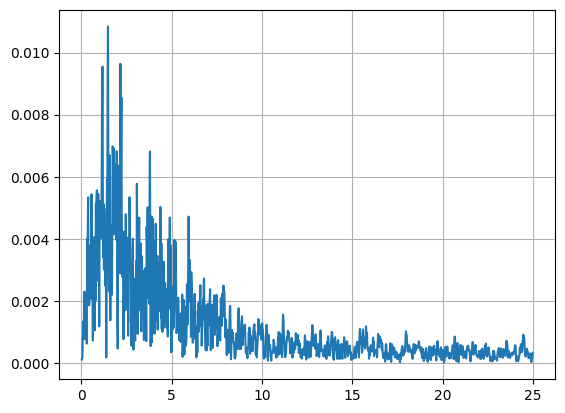

In [30]:
mag = np.zeros((len(a_n),1))
wf = np.zeros((len(a_n),1))
freq = np.zeros((len(a_n), 1))

dt = (data[1,0]-data[0,0])
fs = 1/dt

for j in range(len(a_n)):
  mag[j,:] = np.sqrt(a_n[j]**2 + b_n[j]**2)
  #wf[j,:] = 2*np.pi*(j+1)/n
  freq[j,:] = (j+1) * fs / n

print(mag)

#plt.plot(wf,mag)
plt.plot(freq, mag)
plt.grid(True)
plt.show()

In [ ]:
max_index = np.argmax(mag)
max_index

78

In [ ]:
mag[max_index]

array([0.01083891])

In [ ]:
# 최대값에 해당하는 진동수 찾기
freq[max_index]


array([1.46949405])

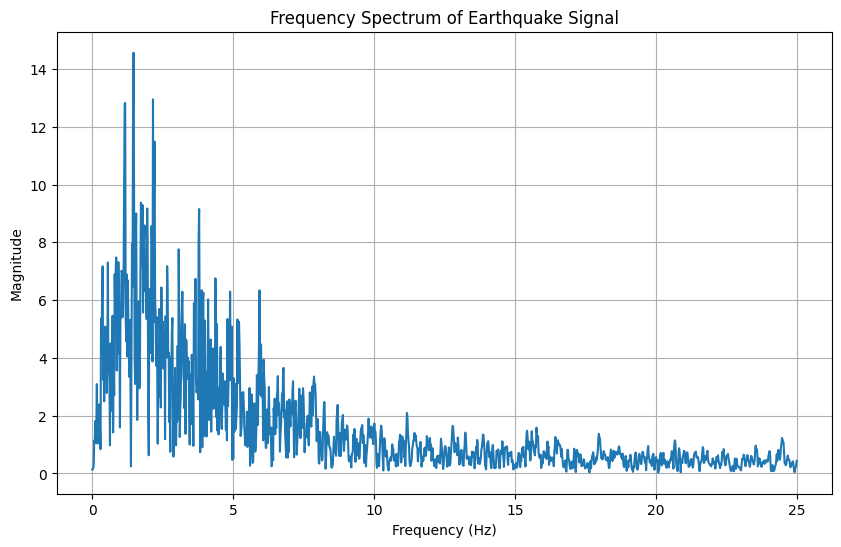

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 지진파 데이터 로드
filename = 'elcentro.txt'
data = np.loadtxt(filename)
n = len(data)

# 샘플링 주기 (예시로 0.02초 설정)
dt = 0.02
t = np.arange(0, n*dt, dt)

# FFT 수행
fft_result = np.fft.fft(data[:,1])
frequencies = np.fft.fftfreq(n, dt)

# 주파수 스펙트럼의 절대값 계산 (진폭)
magnitude = np.abs(fft_result)
#magnitude = 2 * np.abs(fft_result[:n//2]) / n

# 양의 주파수 성분만 고려
positive_frequencies = frequencies[:n//2]
positive_magnitude = magnitude[:n//2]

# 주파수 스펙트럼 시각화
plt.figure(figsize=(10, 6))
plt.plot(positive_frequencies, positive_magnitude)
plt.title('Frequency Spectrum of Earthquake Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid()
plt.show()


In [ ]:
# 최대값에 해당하는 진동수 찾기
idx = np.argmax(positive_magnitude)
positive_frequencies[idx]

1.4694940476190477

# FFT vs Amplitude vs Power Spectrum vs Power Spectral Density

# 0. FFT의 absolute value

In [31]:
import numpy as np
import matplotlib.pyplot as plt

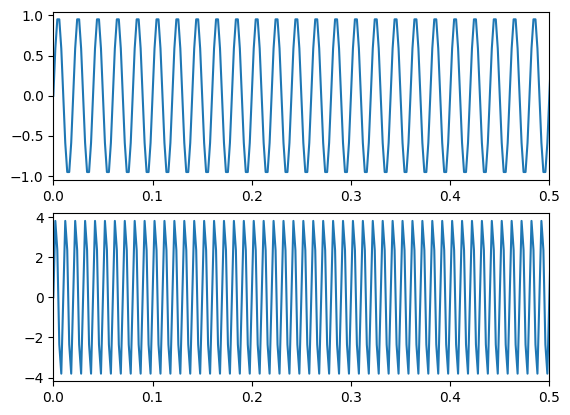

In [32]:

# time serise
fs = 500
t = np.arange(0, 5-1/fs, 1/fs)
freq = np.arange(0, fs-1/fs,fs/len(t))
A = np.array([1,4]).reshape(2,1) # amplitude
f = np.array([50,100]).reshape(2,1)  # frequency


xn = A*np.sin(2*np.pi*f*t)
N = len(xn[0])

plt.subplot(2,1,1)
plt.plot(t,xn[0,:])
plt.xlim(0,0.5)
plt.subplot(2,1,2)
plt.plot(t,xn[1,:])
plt.xlim(0,0.5)
plt.show()

In [33]:
# double-side fft
Y = np.fft.fft(xn)

Y

array([[0.58778525+0.j        , 0.58779012+0.00386914j,
        0.58780471+0.00773864j, ..., 0.58782903-0.01160886j,
        0.58780471-0.00773864j, 0.58779012-0.00386914j],
       [3.80422607+0.j        , 3.80423477+0.00692124j,
        3.80426087+0.01384263j, ..., 3.80430438-0.02076431j,
        3.80426087-0.01384263j, 3.80423477-0.00692124j]])

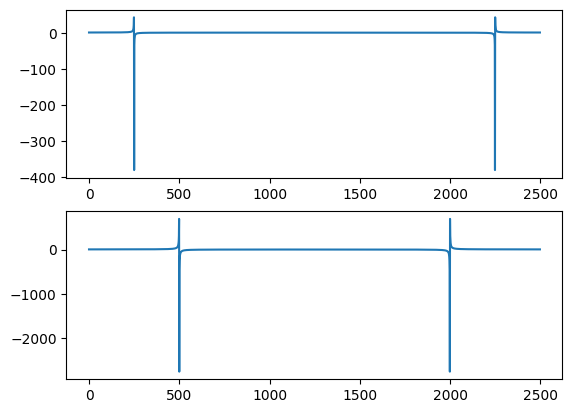

In [34]:
plt.subplot(2,1,1)
plt.plot(Y[0,:])
plt.subplot(2,1,2)
plt.plot(Y[1,:])
plt.show()

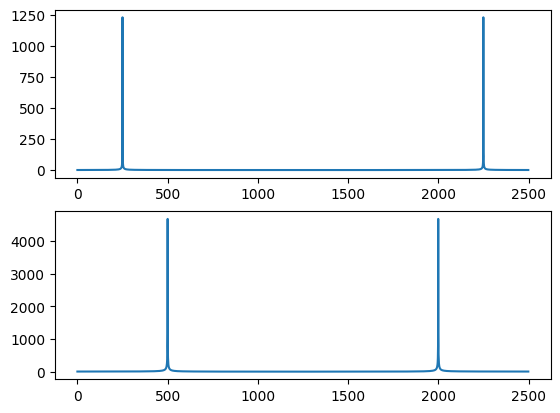

In [35]:
# abs(fft)
plt.subplot(2,1,1)
plt.plot(np.abs(Y[0,:]))
plt.subplot(2,1,2)
plt.plot(np.abs(Y[1,:]))
plt.show()

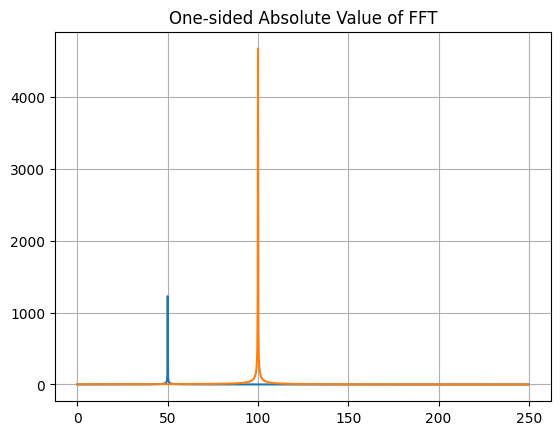

In [36]:
# one-sided FFT의 abs는 물리적 의미가 없다.

plt.plot(freq[:N//2],np.abs(Y[0,:N//2]),freq[:N//2],np.abs(Y[1,:N//2]))   # negative frequency는 무시
plt.grid()
plt.title('One-sided Absolute Value of FFT')
plt.show()

# 1. Amplitude of FFT
- to start with, Amplitude = 1/N * abs(fft)
- abs(fft) consists of postive and negative
- to sum up, take 2/N
#- thus, Amplitude = 2/N * abs(fft)  

In [ ]:
# Amplitude Spectrum from FFT
xk = np.abs(Y)/N  # 면적에서 밑변의 길이(샘플의 개수)로 나눠줘서 크기를 정규화 (평균 크기를 유지)
xk =xk[:,:N//2]
xk[:,1:-1] *= 2  # 음의 주파수와 양의 주파수를 더하기

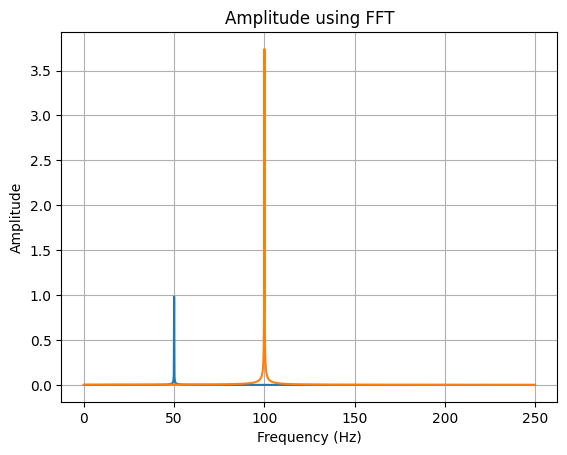

In [ ]:
# 실제 물리적 Amplitude와 동일함
plt.plot(freq[0:N//2],xk[0,:],freq[0:N//2],xk[1,:])
plt.grid()
plt.title('Amplitude using FFT')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.show()

# 2. Power (제곱) of Amplitude
- abs(fft)/N = Amp/2
- 양변 제곱하면 {abs(fft)/N }^2 = A^2 / 4
- one-sided니깐 X2를 하면 A^2 /2


$\text{Power} = \frac{2 \cdot \left| \text{FFT} \right|^2}{N^2}$


In [ ]:
xk_p = 1/N**2 * np.abs(Y)**2  # one side power spectrum
xk_p = xk_p[:, :N//2]

xk_p[:, 1:-1] *= 2  # Nyquist frequency 제외하고 값을 2배로

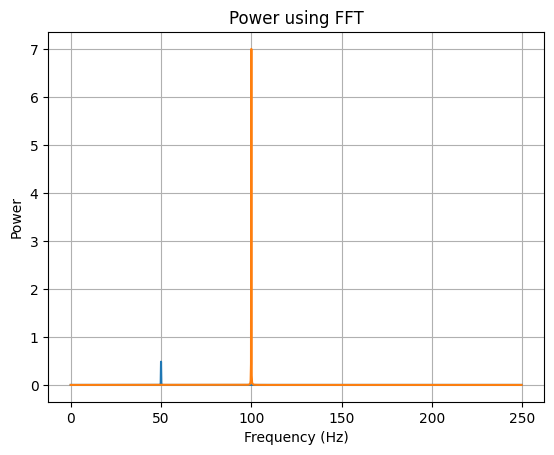

In [ ]:

plt.plot(freq[0:N//2],xk_p[0,:],freq[0:N//2],xk_p[1,:])
plt.grid()
plt.title('Power using FFT')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.show()

# Scipy.signal 모듈로 파워 스펙트럼 그리기

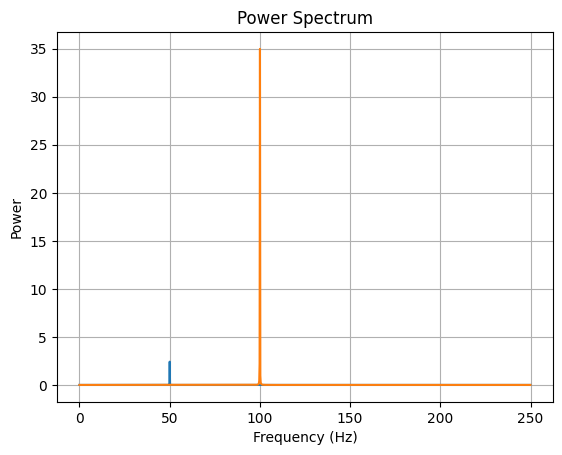

In [ ]:
from scipy.signal import periodogram

# 파워 스펙트럼 계산
freqs, power_spectrum = periodogram(xn, fs)

# 파워 스펙트럼 시각화
plt.plot(freqs, power_spectrum[0,:],freqs, power_spectrum[1,:])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Power Spectrum')
plt.grid()
plt.show()

# 3 Welch 명령어를 이용한 Power Spectral Density

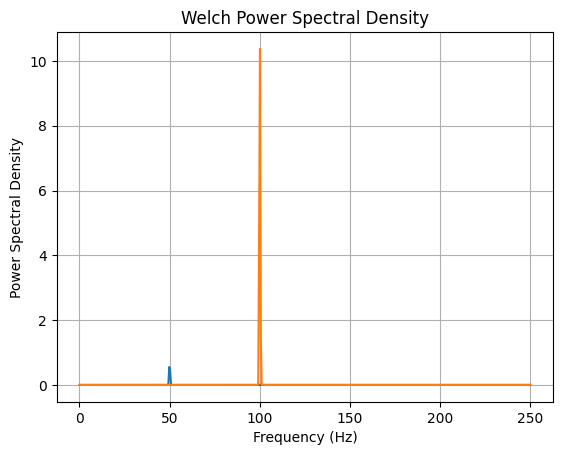

In [ ]:
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

# Welch 파워 스펙트럼 밀도 계산
freqs, psd = welch(xn, fs, nperseg=1024)

# 결과 플로팅
plt.plot(freqs, psd[0,:],freqs, psd[1,:])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Welch Power Spectral Density')
plt.grid(True)
plt.show()

In [ ]:
freqs.shape

(513,)

In [ ]:
psd.shape

(2, 513)

# El Centro

In [ ]:
# 데이터 로드
filename = 'elcentro.txt'
data = np.loadtxt(filename)

# 샘플 수 및 샘플링 주기 설정
n = len(data)
t = np.arange(n)

RMS 값: 0.04691958470571626


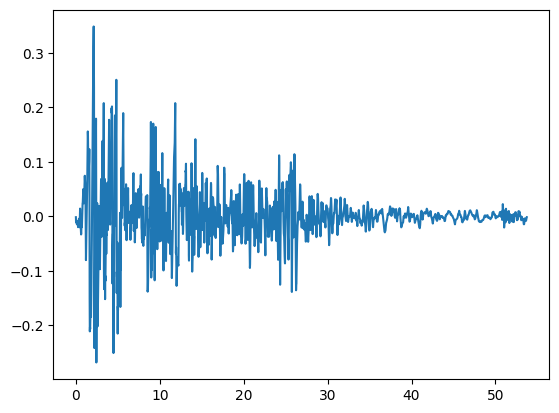

In [ ]:
xn = data[:,1].T
t = data[:,0].T
rms = np.sqrt(np.mean(xn**2))

print(f"RMS 값: {rms}")

plt.plot(t,xn)
plt.show()

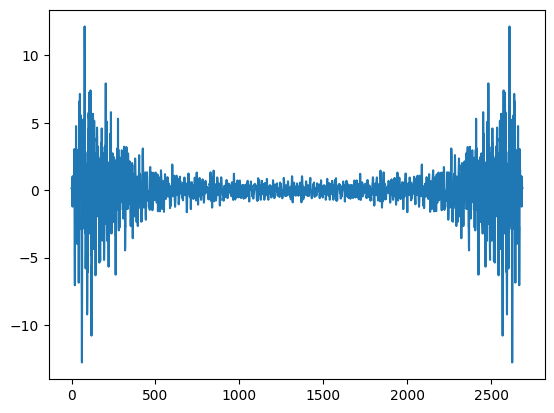

In [ ]:
# double-side fft
Y = np.fft.fft(xn)

plt.plot(Y)


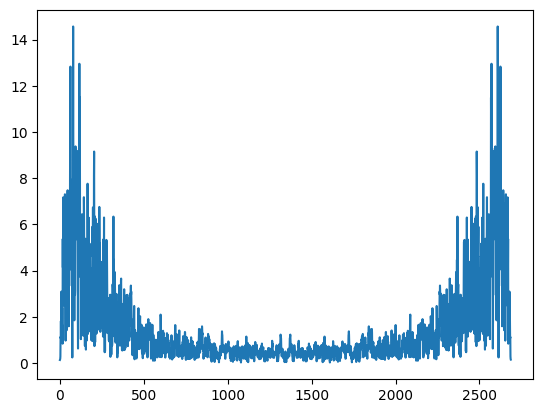

In [ ]:
# abs(fft)
plt.plot(np.abs(Y))


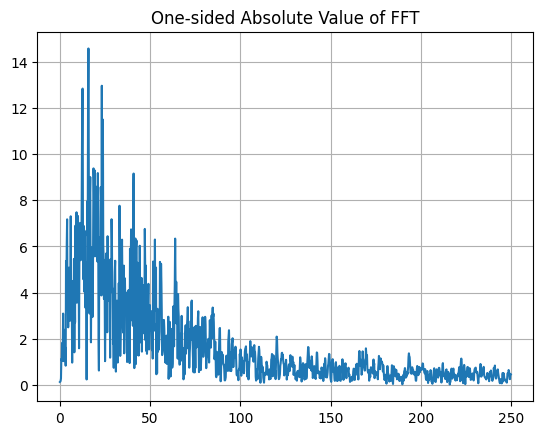

In [ ]:
# one-sided FFT의 abs는 물리적 의미가 없다.

plt.plot(freq[:N//2],np.abs(Y[:N//2]))   # negative frequency는 무시
plt.grid()
plt.title('One-sided Absolute Value of FFT')
plt.show()

In [ ]:
# Amplitude Spectrum from FFT
xk = np.abs(Y)/N
xk =xk[:N//2]
xk[1:-1] *= 2

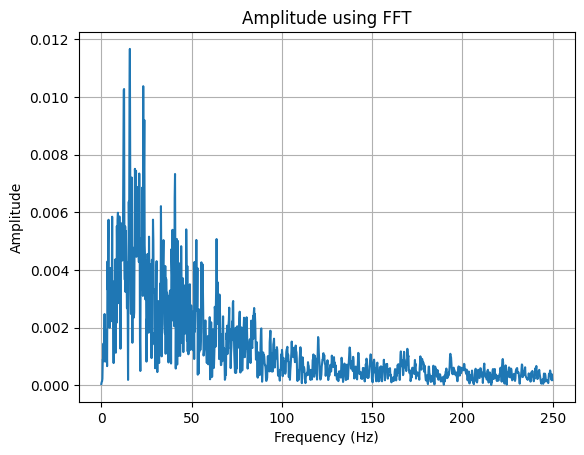

In [ ]:
# 실제 물리적 Amplitude와 동일함
plt.plot(freq[:N//2],xk)
plt.grid()
plt.title('Amplitude using FFT')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.show()

In [ ]:
np.max(xk)


0.011658654677322234

In [ ]:
xk_p = 1/N**2 * np.abs(Y)**2  # one side power spectrum
xk_p = xk_p[:N//2]

xk_p[1:-1] *= 2  # Nyquist frequency 제외하고 값을 2배로

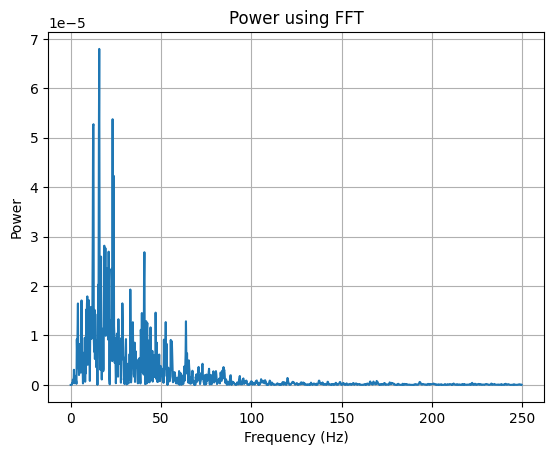

In [ ]:
plt.plot(freq[:N//2],xk_p)
plt.grid()
plt.title('Power using FFT')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.show()

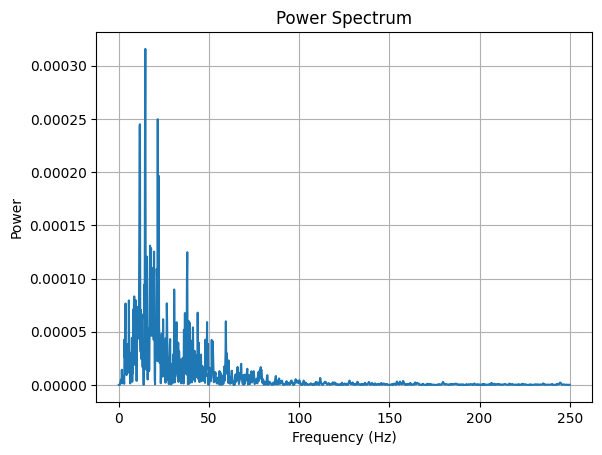

In [ ]:
from scipy.signal import periodogram

# 파워 스펙트럼 계산
freqs, power_spectrum = periodogram(xn, fs)

# 파워 스펙트럼 시각화
plt.plot(freqs, power_spectrum)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.title('Power Spectrum')
plt.grid()
plt.show()

# 자기 상관 함수

In [ ]:
# El Centro의 자기 상관 함수

mean = np.mean(xn)  # 지진파 평균
var = np.var(xn)  # 지진파 분산

Rtt = []
for lag in range(len(xn)):
  autocorr = np.sum((xn[:n-lag]-mean)*(xn[lag:]-mean))/var/len(xn)
  Rtt.append(autocorr)



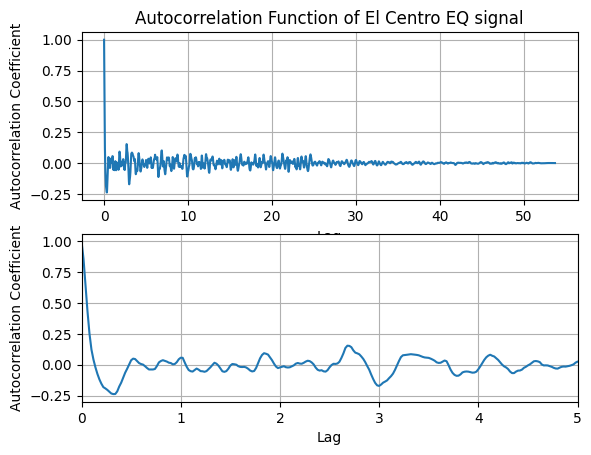

In [ ]:
plt.subplot(2,1,1)
plt.plot(t,Rtt)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation Coefficient')
plt.title('Autocorrelation Function of El Centro EQ signal')
plt.grid()
plt.subplot(2,1,2)
plt.plot(t,Rtt)
plt.xlim(0,5)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation Coefficient')
plt.grid()
plt.show()

In [ ]:
# Power spectrum of Autocorrelation function

YR = np.fft.fft(Rtt)

xk_p = 1/N**2 * np.abs(YR)**2  # one side power spectrum
xk_p = xk_p[:N//2]

xk_p[1:-1] *= 2  # Nyquist frequency 제외하고 값을 2배로

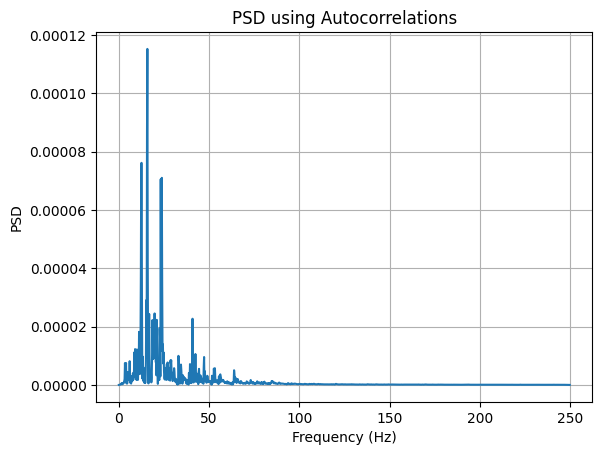

In [ ]:
plt.plot(freq[:N//2],xk_p)
plt.grid()
plt.title('PSD using Autocorrelations')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.show()

In [ ]:
# PSD의 면적

df = freq[1]-freq[0]
area = np.sum(xk_p*df)
print(area)

0.0004253173152374514


# SCIPY 모듈의 WELCH PSD

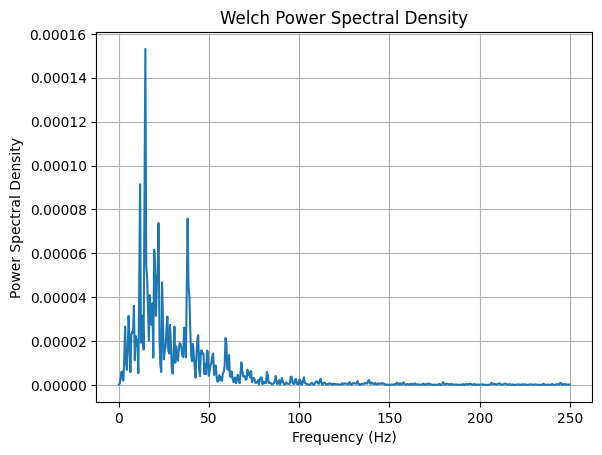

In [ ]:
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

# Welch 파워 스펙트럼 밀도 계산
freqs, psd = welch(xn, fs, nperseg=1024)    # time serie는 1Xn의 형태로 입력

# 결과 플로팅
plt.plot(freqs, psd)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Welch Power Spectral Density')
plt.grid(True)
plt.show()

In [ ]:
# PSD의 면적

area_w = np.sum(psd*freqs)/2   # one sided로 하면서 2를 곱해줬기 때문에 2로 나눠줘야 함.
print(area_w)

0.0496004501305109


In [ ]:
freqs[1]-freqs[0]

0.48828125

In [ ]:
rms = np.sqrt(np.mean(xn**2))
print(rms)

0.04691958470571626


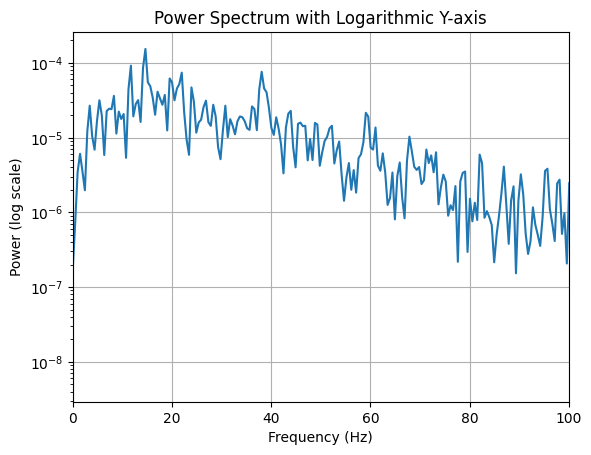

In [ ]:
plt.plot(freqs, psd)
plt.yscale('log')  # y축을 로그 스케일로 설정
plt.xlim(0,100)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (log scale)')
plt.title('Power Spectrum with Logarithmic Y-axis')
plt.grid(True)
plt.show()

In [44]:
# 데이터 로드
# setup2.txt(4채널 계측 가속도, fs=200Hz)는 용량(11.6MB) 때문에 저장소에 넣지 않았습니다.
# 파일이 있으면 그 데이터를, 없으면 같은 형식의 교육용 합성 데이터를 씁니다.
import os
filename = 'setup2.txt'
if os.path.exists(filename):
    data = np.loadtxt(filename)
else:
    print('setup2.txt 없음 -> 교육용 합성 데이터(4채널, 1.2/3.8/6.5 Hz 모드 + 잡음) 사용')
    rng = np.random.default_rng(0)
    fs_demo, dur = 200, 600
    tt = np.arange(0, dur, 1/fs_demo)
    modes = [(1.2, 0.02), (3.8, 0.02), (6.5, 0.02)]
    shapes = np.array([[0.25, 0.7, 1.0], [0.5, 1.0, 0.3], [0.75, 0.6, -0.8], [1.0, -0.6, 0.5]])
    data = np.zeros((len(tt), 4))
    for j, (f, z) in enumerate(modes):
        wn = 2*np.pi*f; wd = wn*np.sqrt(1 - z**2)
        h = np.exp(-z*wn*tt[:2000])*np.sin(wd*tt[:2000])  # 단자유도 충격응답
        q = np.convolve(rng.standard_normal(len(tt)), h)[:len(tt)]
        data += np.outer(q/np.std(q), shapes[:, j])
    data = 1e-5*data + 2e-7*rng.standard_normal(data.shape)

# 샘플 수 및 샘플링 주기 설정
n = len(data)


setup2.txt 없음 -> 교육용 합성 데이터(4채널, 1.2/3.8/6.5 Hz 모드 + 잡음) 사용


In [45]:
data.shape

(120000, 4)

In [46]:
n

120000

In [47]:
fs = 200
t = np.arange(0, n/fs, 1/fs)
freq = np.arange(0, fs-1/fs,fs/n)

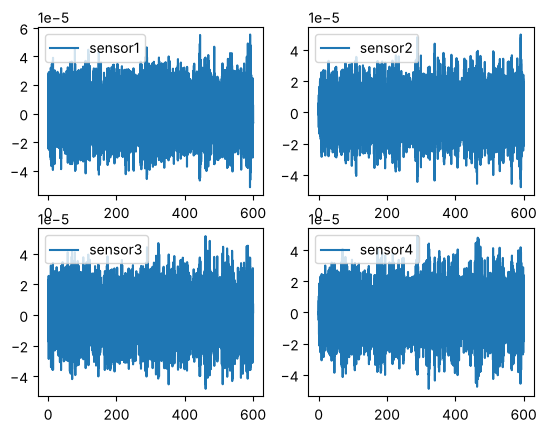

In [48]:
xn = data
rms = np.sqrt(np.mean(xn**2))

#print(f"RMS 값: {rms:.5f}")

plt.subplot(2,2,1)
plt.plot(t,xn[:,0],label ='sensor1')
plt.legend()
plt.subplot(2,2,2)
plt.plot(t,xn[:,1],label ='sensor2')
plt.legend()
plt.subplot(2,2,3)
plt.plot(t,xn[:,2],label ='sensor3')
plt.legend()
plt.subplot(2,2,4)
plt.plot(t,xn[:,3],label ='sensor4')
plt.legend()

plt.show()

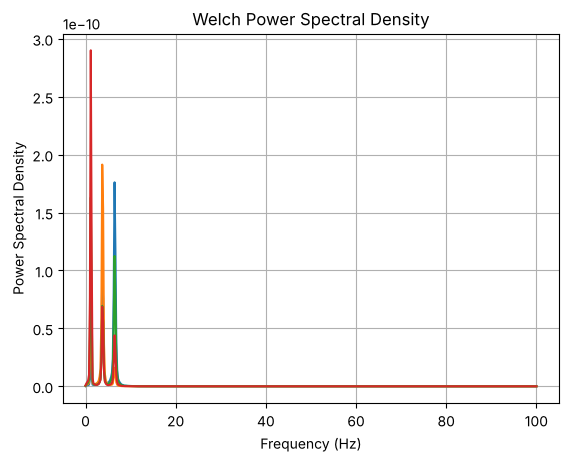

In [49]:
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

# Welch 파워 스펙트럼 밀도 계산
freqs, psd = welch(xn.T, fs, nperseg=1024)  # time serie는 1Xn의 형태로 입력

# 결과 플로팅
plt.plot(freqs, psd[0,:],freqs, psd[1,:],freqs, psd[2,:],freqs, psd[3,:])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density')
plt.title('Welch Power Spectral Density')
plt.grid(True)
plt.show()

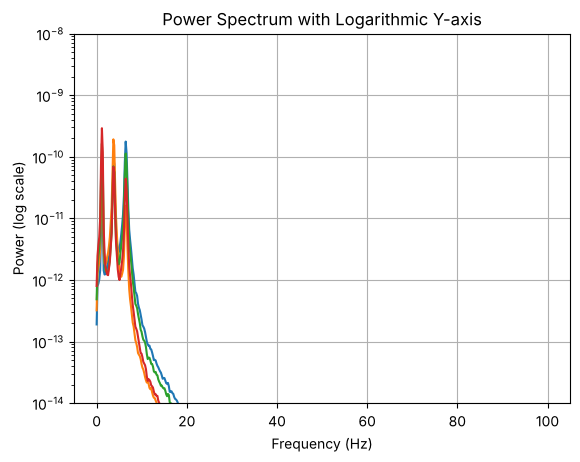

In [50]:
plt.plot(freqs, psd[0,:],freqs, psd[1,:],freqs, psd[2,:],freqs, psd[3,:])
plt.yscale('log')  # y축을 로그 스케일로 설정
plt.ylim(10**-14,10**-8)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (log scale)')
plt.title('Power Spectrum with Logarithmic Y-axis')
plt.grid(True)
plt.show()